In [1]:
%load_ext autoreload
%autoreload 2

from modules.data_services.data_utils import load_btc_benchmark
from modules.visualization.plots import plot_positions, plot_pnl, plot_zscore
from modules.performance.strategy import Strategy

In [2]:
interval = "1h"
fee_rate = 0.0005
initial_cash = 100000
risk_free_rate = 0

ticker_x = "ETHUSDT"
ticker_y = "UNIUSDT"

beta_opt_start = "2024-01-01"
opt_start = "2024-02-01"
opt_end = "2024-03-01"

beta_test_start = "2024-02-01"
test_start = "2024-03-01"
test_end = "2024-04-01"

In [3]:
bt_1 = Strategy(
    ticker_x=ticker_x,
    ticker_y=ticker_y,
    start=beta_opt_start,
    end=test_end,
    interval=interval,
    fee_rate=fee_rate,
    initial_cash=initial_cash,
    risk_free_rate_annual=risk_free_rate,
    window="rolling",
    source="log",
    beta_hedge=None,
)

In [4]:
from skopt.space import Real

static_params = {
    # "stop_loss": 2
}
param_space = [
    Real(0.5, 2, name="window_factor"),
    Real(1.01, 4.00, name="entry_threshold"),
    Real(0.0, 1.00, name="exit_threshold"),
    Real(1.01, 2.00, name="stop_loss"),
]

metric = ("sortino_ratio_annual", "net")

In [5]:
best_params, best_score = bt_1.run_optimization(
    static_params=static_params,
    param_space=param_space,
    metric=metric,
    opt_start=opt_start,
    opt_end=opt_end,
    beta_opt_start=beta_opt_start,
    n_iter=50,
    random_state=42,
    replicates=1,
    penalty_bad=-100,
)

window_factor = best_params["window_factor"]
entry_threshold = best_params["entry_threshold"]
exit_threshold = best_params["exit_threshold"]
stop_loss = best_params["stop_loss"]

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 3.5110
Function value obtained: -12.9504
Current minimum: -12.9504
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 3.4753
Function value obtained: -13.9924
Current minimum: -13.9924
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 3.5124
Function value obtained: -17.3021
Current minimum: -17.3021
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 3.5317
Function value obtained: -12.9102
Current minimum: -17.3021
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 4.6278
Function value obtained: -10.5682
Current minimum: -17.3021
Iteration No: 6

In [6]:
print(window_factor, entry_threshold, exit_threshold, stop_loss)

0.8170848434107272 3.436107476806365 0.0 1.7712646333147217


In [7]:
opt_1 = bt_1.run_strategy(
    entry_threshold=entry_threshold,
    exit_threshold=exit_threshold,
    stop_loss=stop_loss,
    test_start=opt_start,
    test_end=opt_end,
    beta_test_start=beta_opt_start,
    window_factor=window_factor,
)

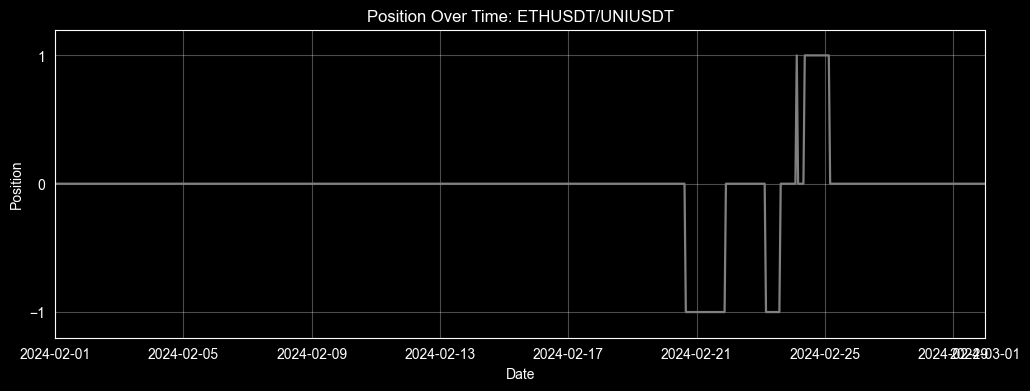

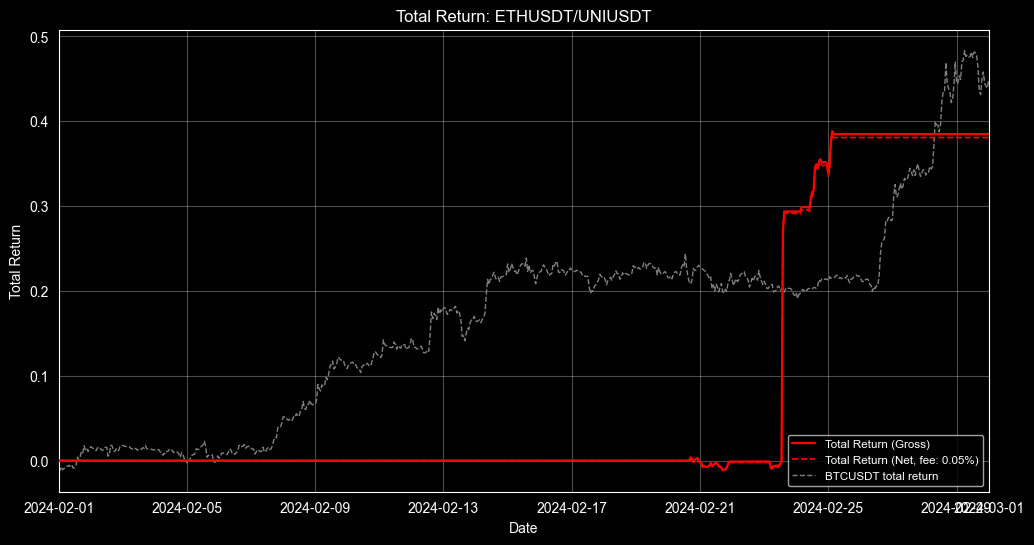

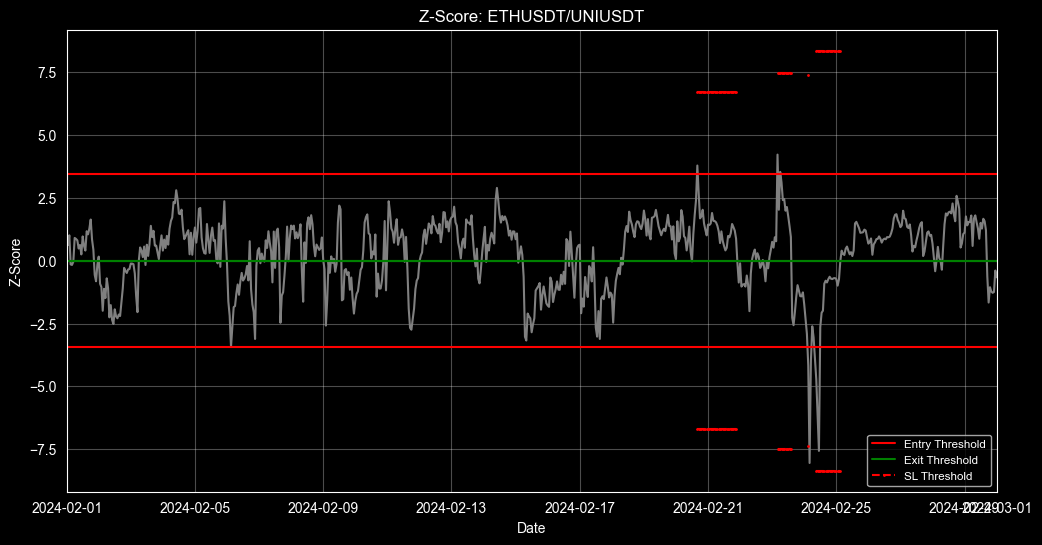

In [8]:
plot_positions(opt_1, show=True)
btc_data = load_btc_benchmark(
    test_start=opt_start,
    test_end=opt_end,
    interval=interval,
)
plot_pnl(opt_1, btc_data, show=True)
plot_zscore(opt_1, show=True, sl_thr=True)

In [9]:
# opt_1.data

In [10]:
opt_1.stats

,gross,net
metric,,
total_return,0.3850,0.3809
cagr,58.9346,56.7346
volatility,0.0104,0.0104
volatility_annual,0.9746,0.9760
max_drawdown,-0.0152,-0.0152
win_count,3.0000,3.0000
lose_count,1.0000,1.0000
win_rate,0.7500,0.7500
max_win,0.2947,0.2941


In [11]:
result_1 = bt_1.run_strategy(
    entry_threshold=entry_threshold,
    exit_threshold=exit_threshold,
    stop_loss=stop_loss,
    test_start=test_start,
    test_end=test_end,
    beta_test_start=beta_test_start,
    window_factor=window_factor,
)

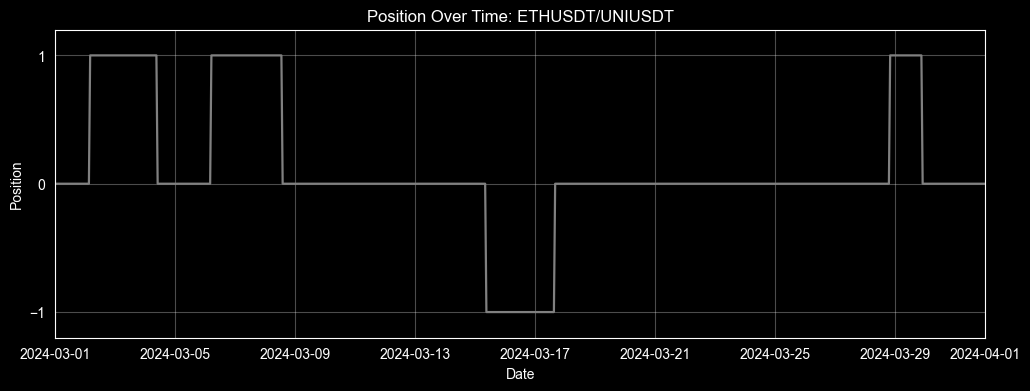

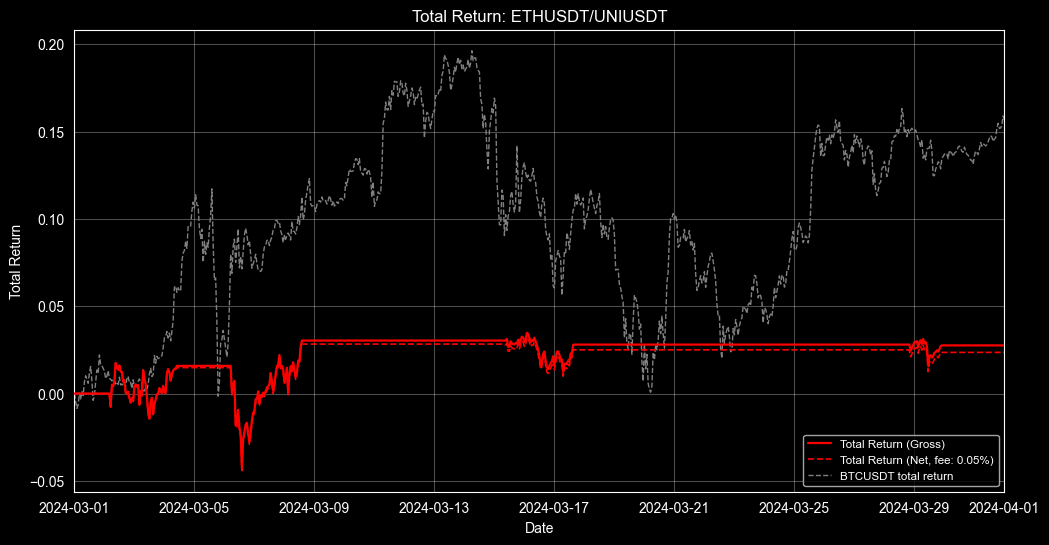

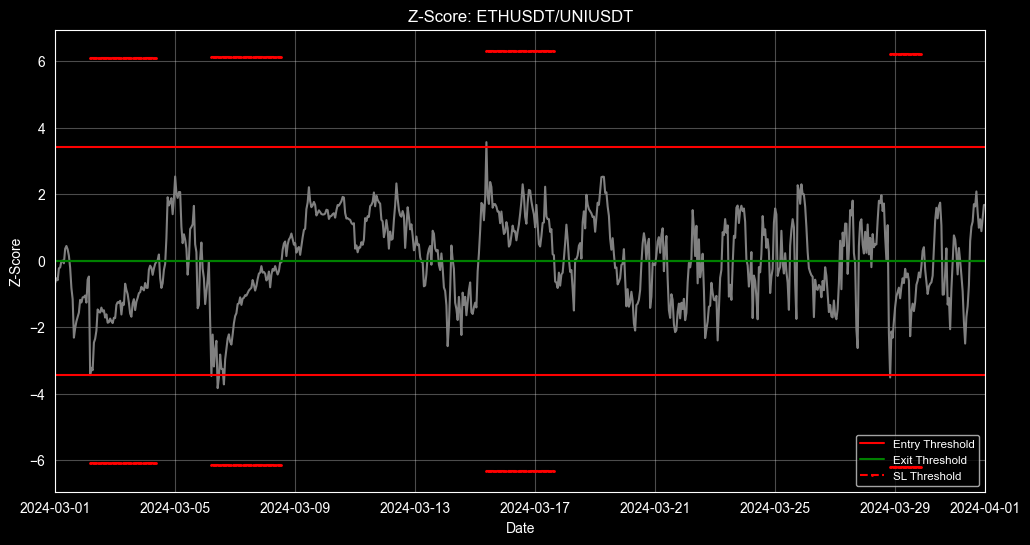

In [12]:
plot_positions(result_1, show=True)
btc_data = load_btc_benchmark(
    test_start=test_start,
    test_end=test_end,
    interval=interval,
)
plot_pnl(result_1, btc_data, show=True)
plot_zscore(result_1, show=True, sl_thr=True)

In [13]:
# result_1.data

In [14]:
result_1.stats

,gross,net
metric,,
total_return,0.0276,0.0236
cagr,0.3772,0.3154
volatility,0.0026,0.0026
volatility_annual,0.2463,0.2466
max_drawdown,-0.0592,-0.0603
win_count,2.0000,2.0000
lose_count,2.0000,2.0000
win_rate,0.5000,0.5000
max_win,0.0159,0.0154


In [15]:
result_1.stats

,gross,net
metric,,
total_return,0.0276,0.0236
cagr,0.3772,0.3154
volatility,0.0026,0.0026
volatility_annual,0.2463,0.2466
max_drawdown,-0.0592,-0.0603
win_count,2.0000,2.0000
lose_count,2.0000,2.0000
win_rate,0.5000,0.5000
max_win,0.0159,0.0154


In [16]:
# result_1.data